# Per-block strengths $s=(s_1,s_2,s_3)$ for non-reversible anchored Langevin

**Can the non-reversible arm be pushed harder by giving each block its own rotation
strength?** Titanic, ball constraint, exact gradient, LASSO-anchored potential.

$$w_{k+1}=\Pi_K\Big[w_k-\eta\,a(w_k)\nabla U_0(w_k)+\eta\,\alpha\,a(w_k)J_s(w_k)\nabla U_0(w_k)
+\sqrt{2\eta a(w_k)}\,\xi_{k+1}\Big]$$

$J_s$ is block diagonal on the coordinate triples $(1,2,3),(4,5,6),(7,8,9)$, block $\ell$
carrying its own strength $s_\ell$. $\alpha=0$ is the reversible arm, $\alpha=1$ the
non-reversible one.

### What is settled before any of this runs

$J$'s three conditions — $J^\top=-J$, $\operatorname{div}J=0$, $Jn=0$ on $\partial K$ — involve
only the constraint set $K$, never the potential, and the anchor cancellation needs only
$a=e^{U-U_0}$. **So every triple $s$ leaves both arms sharing the same invariant law
$\pi_K\propto e^{-U}\mathbf1_K$.** No $s$ beats the reversible arm on a stationary quantity, and
predictive accuracy is one. That is not re-argued here; it is measured alongside, so the claim
can be checked rather than believed.

### What is open, and why per-block $s$ should matter

The companion study `regularizer_study.py` found that the non-reversible speed-up is driven by
the anisotropy **inside** the triples $J$ rotates and is blind to anisotropy **across** them.
Each block has its own within-block anisotropy, so the right strength for block 1 need not be
the right strength for block 3. This notebook tests that, and it is a different rule from the
gradient-scale heuristic $s_\ell\propto 1/(r_\ell\|\nabla_{I_\ell}U_0\|)$ recorded earlier in
this repository's README.

### The trap this notebook is built around

The ESS ratio **rises monotonically in $s$**, so a naive `argmax ESS` search returns the largest
strength on any grid — where the chain is fast and *wrong*. An earlier version of this search did
exactly that and reported a 7× "speed-up" at $s=20$ that cost 7–10 percentage points of accuracy
at split-$\hat R=1.5$. Every selection below is therefore made **under a discretisation-bias
constraint**, measured against a gold reference run at $\eta/10$. Section 6 shows the
unconstrained curves so the trap is visible rather than described.

---
## 1. Configuration

In [1]:
from __future__ import annotations

import json
import math
import os
import platform
import sys
import time
from typing import Dict, Sequence, Tuple

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.special import expit

import exact_nb as X                                                          # noqa: E402
from exact_nb import D10, design_with_intercept, softplus                     # noqa: E402
from nral import _wrap, build_titanic_dataset                                 # noqa: E402
from probe_mixing import iact_geyer, split_rhat                               # noqa: E402

# AFTER the repository imports, not before: probe_mixing pulls in exact_anchored, which forces the
# Agg backend at module level, and that would leave every figure below invisible in the notebook.
try:
    get_ipython().run_line_magic("matplotlib", "inline")              # type: ignore[name-defined]
except Exception:
    matplotlib.use("Agg")

BLOCKS = X.BLOCKS10                     # ((1,2,3), (4,5,6), (7,8,9)); the intercept is never rotated
ETA = 1e-4
SEED_SEARCH, SEED_CONF, SEED_GOLD = 8100, 9200, 8107   # disjoint; used nowhere else in the repo
LAM1_FRAC, LAM2_FRAC = 0.01, 0.05
LEVELS = (1.0, 2.0, 5.0, 10.0, 20.0)
GRADED_K = (1.0, 5.0, 25.0)             # per-block within-block anisotropy, by construction
CK = 2
THIN_BIAS = 8
GOLD_DIV = 10.0

# DECLARED IN ADVANCE.  The reversible arm ignores s entirely, so its discretisation bias at this
# eta is one fixed number per potential.  A cell is admissible if the non-reversible arm's bias is
# at most CAP_MULT times it.  An exact match is the wrong rule: at small s the true bias sits below
# the Monte Carlo floor of the gold reference, so an exact cap rejects cells on rounding noise.
CAP_MULT = 2.0
BSTARS = (0.10, 0.25, 0.50)             # fixed thresholds, reported alongside, never used to select

QUICK = os.environ.get("BNB_MODE", "full").lower() == "quick"
R_G, NM_G = (8, 3000) if QUICK else (32, 160_000)          # gold
R_S, NB_S, NM_S = (12, 400, 1200) if QUICK else (32, 3000, 10_000)      # search
R_C, NB_C, NM_C = (16, 400, 1500) if QUICK else (96, 4000, 16_000)      # confirmation

# validated 3-slot categorical palette (dataviz reference instance; normal dE 27.6, worst CVD
# dE 9.2 deutan; the aqua slot carries a contrast WARN, relieved by direct labels + printed tables)
BLK = ("#2a78d6", "#eb6834", "#1baf7a")
INK, INK2, INK3, GRIDC = "#1f2328", "#57606a", "#8c959f", "#e4e6ea"
REV, NREV = "#1f5fbf", "#1a9850"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRIDC,
    "axes.linewidth": 0.8, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False,
    "grid.color": GRIDC, "grid.linewidth": 0.7, "grid.linestyle": "-", "font.size": 9,
})
RESULTS_DIR = os.environ.get("BNB_RESULTS", os.path.join(os.getcwd(), "results", "blocks_nb"))
FIGURE_DIR = os.environ.get("BNB_FIGURES", os.path.join(os.getcwd(), "figures", "blocks_nb"))
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
CHECKS: Dict[str, object] = {}

versions: {'python': '3.11.15', 'platform': 'Linux-6.18.44-fc-v37-x86_64-with-glibc2.39', 'numpy': '2.4.6', 'scipy': '1.17.1', 'sklearn': '1.9.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}
mode: full | R_MAIN=100  R_ETA=150  R_CONF=1500


In [2]:
print("versions:", {"python": sys.version.split()[0], "numpy": np.__version__,
                    "scipy": scipy.__version__, "pandas": pd.__version__,
                    "matplotlib": matplotlib.__version__})
print("mode:", "QUICK (a smoke test, NOT the experiment)" if QUICK else "full")
print(f"  gold     R={R_G:<4} eta={ETA / GOLD_DIV:g}  {NM_G} it")
print(f"  search   R={R_S:<4} eta={ETA:g}  {NM_S} it   seed {SEED_SEARCH}")
print(f"  confirm  R={R_C:<4} eta={ETA:g}  {NM_C} it   seed {SEED_CONF}")
print(f"  admissibility cap = {CAP_MULT:g} x the reversible arm's own bias (declared in advance)")

versions: {'python': '3.11.15', 'numpy': '2.4.6', 'scipy': '1.17.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}
mode: full
  gold     R=32   eta=1e-05  160000 it
  search   R=32   eta=0.0001  10000 it   seed 8100
  confirm  R=96   eta=0.0001  16000 it   seed 9200
  admissibility cap = 2 x the reversible arm's own bias (declared in advance)


---
## 2. Data and the two potentials

One elastic-net family, so the **anchor is held fixed and only the curvature moves**:

$$U=\underbrace{\sum_j[\operatorname{softplus}(x_j^\top w)-y_jx_j^\top w]+\frac{w_0^2}{2\sigma^2}}_{\text{likelihood + intercept prior}}
+\lambda_1\sum_{j\ge1}|w_j|+\frac{\lambda_2}{2}\sum_{j\ge1}c_jw_j^2$$

with $U_0$ smoothing **only** the $\ell_1$ term, $|w_j|\to\sqrt{w_j^2+\delta^2}$. Then
$a=e^{U-U_0}=\exp(-\lambda_1\sum_j[\sqrt{w_j^2+\delta^2}-|w_j|])$ depends on $(\lambda_1,\delta)$
alone — **identical for both potentials below**, so the anchor is a control, not a confound.

| potential | $\lambda_2$ | $c$ | what it is |
|---|---|---|---|
| `lasso` | $0$ | — | the repository's own regularizer |
| `graded` | $0.05\,n$ | block $\ell$ gets $(1/k_\ell,1,k_\ell)$, $k=(1,5,25)$ | **a different anisotropy in every block**, by construction |

`graded` exists to make the mechanism claim falsifiable: if the gain really tracks within-block
anisotropy, then a potential whose blocks differ by design must have a non-uniform optimum, and
its *isotropic* block ($k_1=1$) must be its least responsive one.

In [3]:
class ElasticPotential:
    """Elastic net on w_1..w_9 with per-coordinate ridge weights c; Gaussian prior on w_0."""

    def __init__(self, Xd, y, sigma, lam1, lam2, c, delta):
        self.X, self.y = Xd, y.astype(float)
        self.sigma, self.lam1, self.lam2, self.delta = sigma, lam1, lam2, delta
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (D10 - 1,)

    def _loglik(self, W):
        z = np.atleast_2d(W) @ self.X.T
        return np.sum(softplus(z) - self.y[None, :] * z, axis=1)

    def _ridge(self, W2):
        return 0.5 * self.lam2 * np.sum(self.c[None, :] * W2[:, 1:] ** 2, axis=1)

    def U(self, W):
        W2 = np.atleast_2d(W)
        out = (self._loglik(W2) + W2[:, 0] ** 2 / (2 * self.sigma ** 2)
               + self.lam1 * np.sum(np.abs(W2[:, 1:]), axis=1) + self._ridge(W2))
        return out[0] if np.ndim(W) == 1 else out

    def U0(self, W):
        W2 = np.atleast_2d(W)
        out = (self._loglik(W2) + W2[:, 0] ** 2 / (2 * self.sigma ** 2)
               + self.lam1 * np.sum(np.sqrt(W2[:, 1:] ** 2 + self.delta ** 2), axis=1)
               + self._ridge(W2))
        return out[0] if np.ndim(W) == 1 else out

    def grad_U0(self, W):
        W2 = np.atleast_2d(W)
        g = (expit(W2 @ self.X.T) - self.y[None, :]) @ self.X
        g[:, 0] += W2[:, 0] / self.sigma ** 2
        g[:, 1:] += (self.lam1 * W2[:, 1:] / np.sqrt(W2[:, 1:] ** 2 + self.delta ** 2)
                     + self.lam2 * self.c[None, :] * W2[:, 1:])
        return g[0] if np.ndim(W) == 1 else g

    def a(self, W):
        W2 = np.atleast_2d(W)
        gap = np.sum(np.sqrt(W2[:, 1:] ** 2 + self.delta ** 2) - np.abs(W2[:, 1:]), axis=1)
        out = np.exp(-self.lam1 * gap)
        return out[0] if np.ndim(W) == 1 else out


def graded_c(ks=GRADED_K) -> np.ndarray:
    """Block l gets the spread (1/k_l, 1, k_l)."""
    return np.concatenate([[1.0 / k, 1.0, k] for k in ks])

In [4]:
DS = build_titanic_dataset()
_Xd, _y = design_with_intercept(DS.X_train), DS.y_train
LAM1 = LAM1_FRAC * DS.n_train
LAM2 = LAM2_FRAC * DS.n_train
DELTA = -math.log(X.A_LOWER) / (9.0 * LAM1)
GEOM = X.make_geom("ball")
POTS = {
    "lasso":  ElasticPotential(_Xd, _y, X.SIGMA, LAM1, 0.0, np.ones(9), DELTA),
    "graded": ElasticPotential(_Xd, _y, X.SIGMA, LAM1, LAM2, graded_c(), DELTA),
}
print(f"titanic: n_train={DS.n_train}  n_test={DS.n_test}  d={D10}")
print(f"lambda_1={LAM1:.4g}  delta={DELTA:.4g}  a in [{np.exp(-LAM1 * 9 * DELTA):.4f}, 1] "
      f"-- IDENTICAL for both potentials")
print(f"lambda_2={LAM2:.4g} (graded only)   c = {np.round(graded_c(), 4).tolist()}")
_w = X.init_unit_ball(np.random.default_rng(0), 4000)
CHECKS["a_identity"] = float(np.max(np.abs(POTS["graded"].a(_w)
                                           - np.exp(POTS["graded"].U(_w) - POTS["graded"].U0(_w)))))
print(f"anchor identity  max|a - exp(U-U_0)| = {CHECKS['a_identity']:.3e}")

titanic: n_train=712  n_test=179  d=10
lambda_1=7.12  delta=0.01082  a in [0.5000, 1] -- IDENTICAL for both potentials
lambda_2=35.6 (graded only)   c = [1.0, 1.0, 1.0, 0.2, 1.0, 5.0, 0.04, 1.0, 25.0]


anchor identity  max|a - exp(U-U_0)| = 1.963e-13


---
## 3. The bias metric and the gold reference

The bias of a cell is measured against a long **reversible** run at $\eta/10$. A reversible
reference is fair to both arms: the continuous process has the same invariant law for both, so
the $\eta\to0$ limit is common to them.

$$\mathrm{BIAS}(\text{cell})=\max_f\frac{|\bar f_{\text{cell}}-\bar f_{\text{gold}}|}{\mathrm{sd}_f(\text{gold})}$$

over thirteen test functions: the ten coordinates, $\|w\|^2$, $U_0$, and **training accuracy**.
Training accuracy is in the set deliberately — a bias metric made only of parameter functionals
can wave through a cell that has visibly moved the thing the study is about. Test labels are used
for nothing here: they appear only in the reported test accuracy, never in a selection.

In [5]:
def test_functions(Ws, pot):
    """(T, R, 10) -> (13, n): the ten coordinates, |w|^2, U_0, and TRAINING accuracy."""
    F = Ws[::THIN_BIAS].reshape(-1, D10)
    acc = np.mean(((F @ pot.X.T) >= 0.0) == pot.y.astype(bool)[None, :], axis=1)
    return np.vstack([F.T, np.sum(F ** 2, axis=1)[None, :], pot.U0(F)[None, :], acc[None, :]])


def gold_reference(pot, geom, *, seed):
    eta_g = ETA / GOLD_DIV
    W0 = X.init_unit_ball(np.random.default_rng(seed + 1), R_G)
    nb = int(NB_S * GOLD_DIV)
    burn = X.run_chain(pot, geom, alpha=0, scales=(0., 0., 0.), eta=eta_g, n_iter=nb,
                       W0=W0, seed=seed, checkpoint_every=max(1, nb // 2))
    r = X.run_chain(pot, geom, alpha=0, scales=(0., 0., 0.), eta=eta_g, n_iter=NM_G,
                    W0=burn["W"][-1], seed=seed + 99, checkpoint_every=int(CK * GOLD_DIV))
    T = test_functions(r["W"], pot)
    return T.mean(axis=1), T.std(axis=1, ddof=1)


def ess_per_chain(S: np.ndarray, ck: int) -> np.ndarray:
    """S is (T, R). Geyer initial-positive/monotone IACT per chain -> ESS in iterations."""
    T, R = S.shape
    out = np.empty(R)
    for r in range(R):
        tau = iact_geyer(S[:, r])
        out[r] = np.nan if not np.isfinite(tau) else T / (2.0 * max(tau, 0.5))
    return out

In [6]:
_t0 = time.perf_counter()
GOLD = {}
for _p, _pot in POTS.items():
    GOLD[_p] = gold_reference(_pot, GEOM, seed=SEED_GOLD)
    print(f"[gold {_p:<6}] eta={ETA / GOLD_DIV:g}  R={R_G}  {NM_G} it   "
          f"[{time.perf_counter() - _t0:.0f}s]")

[gold lasso ] eta=1e-05  R=32  160000 it   [51s]


[gold graded] eta=1e-05  R=32  160000 it   [101s]


---
## 4. One measurement

Both arms start from the **same** stationary state (a shared reversible burn-in) and share the
Gaussian stream, so the comparison is paired and the $s=0$ control is bit-identical. Per
coordinate, Geyer IACT gives a per-chain ESS; the block ratio is the geometric mean over that
block's three coordinates $\times$ all chains.

In [7]:
def measure(pot, geom, scales, *, R, n_burn, n_meas, seed, gold):
    W0 = X.init_unit_ball(np.random.default_rng(seed + 1), R)
    burn = X.run_chain(pot, geom, alpha=0, scales=(0., 0., 0.), eta=ETA, n_iter=n_burn,
                       W0=W0, seed=seed, checkpoint_every=max(1, n_burn // 2))
    Wstat = burn["W"][-1]
    res = {}
    for tag, alpha in (("rev", 0), ("nrev", 1)):
        res[tag] = X.run_chain(pot, geom, alpha=alpha, scales=scales, eta=ETA, n_iter=n_meas,
                               W0=Wstat, seed=seed + 99, checkpoint_every=CK)
        assert res[tag]["n_nonfinite"] == 0, f"non-finite states at s={scales}"

    per_block, logr_all, rhat = [], [], 0.0
    for blk in BLOCKS:
        lr = []
        for j in blk:
            e = {}
            for tag in ("rev", "nrev"):
                S = res[tag]["W"][:, :, j]
                e[tag] = ess_per_chain(S, CK)
                rhat = max(rhat, split_rhat(S))
            ok = np.isfinite(e["rev"]) & np.isfinite(e["nrev"]) & (e["rev"] > 0)
            lr.append(np.log(e["nrev"][ok] / e["rev"][ok]))
        L = np.concatenate(lr)
        logr_all.append(L)
        se = L.std(ddof=1) / np.sqrt(L.size)
        per_block.append((float(np.exp(L.mean())), float(se), float(L.mean() / se)))
    LA = np.concatenate(logr_all)
    seA = LA.std(ddof=1) / np.sqrt(LA.size)

    gm, gs = gold
    bias = {t: float(np.max(np.abs(test_functions(res[t]["W"], pot).mean(axis=1) - gm)
                            / np.maximum(gs, 1e-12))) for t in ("rev", "nrev")}
    acc = {t: X.accuracy(DS.X_test, DS.y_test, res[t]["W"]).mean(axis=0) for t in ("rev", "nrev")}
    d_acc = X.paired(acc["nrev"], acc["rev"])
    return dict(per_block=per_block, overall=float(np.exp(LA.mean())), overall_se=float(seA),
                overall_t=float(LA.mean() / seA), rhat=float(rhat),
                bias_rev=bias["rev"], bias_nrev=bias["nrev"],
                acc_rev=float(acc["rev"].mean()), acc_nrev=float(acc["nrev"].mean()),
                d_acc_pts=d_acc[0] * 100.0, t_acc=d_acc[2],
                proj_rev=res["rev"]["projection_rate"], proj_nrev=res["nrev"]["projection_rate"])

In [8]:
_r0 = X.run_chain(POTS["lasso"], GEOM, alpha=0, scales=(5., 5., 5.), eta=ETA, n_iter=300,
                  W0=X.init_unit_ball(np.random.default_rng(7), 16), seed=7)
_r1 = X.run_chain(POTS["lasso"], GEOM, alpha=1, scales=(0., 0., 0.), eta=ETA, n_iter=300,
                  W0=X.init_unit_ball(np.random.default_rng(7), 16), seed=7)
CHECKS["s0_control_bit_identical"] = float(np.max(np.abs(_r0["W"] - _r1["W"])))
print(f"PAIRING CONTROL: alpha=1 with s=(0,0,0) vs alpha=0, same W0 and seed -> "
      f"max |difference| = {CHECKS['s0_control_bit_identical']:.3e}")
assert CHECKS["s0_control_bit_identical"] == 0.0, "with J = 0 the two arms must be bit-identical"
print("  bit-identical, so every paired standard error below is meaningful.")

PAIRING CONTROL: alpha=1 with s=(0,0,0) vs alpha=0, same W0 and seed -> max |difference| = 0.000e+00
  bit-identical, so every paired standard error below is meaningful.


---
## 5. Stage A — per-block response curves

For each block $\ell$, scan $s_\ell$ with the **other two blocks held at zero**. That isolates
block $\ell$'s own response: its gain, and the strength at which its discretisation bias breaks.
A uniform scan $s=(v,v,v)$ runs in the same stage as the baseline to beat. Search seed 8100.

In [9]:
_rows, _t0 = [], time.perf_counter()
for _p, _pot in POTS.items():
    for _b in range(3):
        for _v in LEVELS:
            _sc = [0.0, 0.0, 0.0]
            _sc[_b] = _v
            _m = measure(_pot, GEOM, tuple(_sc), R=R_S, n_burn=NB_S, n_meas=NM_S,
                         seed=SEED_SEARCH, gold=GOLD[_p])
            _rows.append(dict(potential=_p, mode=f"block{_b + 1}", target_block=_b + 1, s=_v,
                              own_ratio=_m["per_block"][_b][0], own_t=_m["per_block"][_b][2],
                              overall=_m["overall"], bias_nrev=_m["bias_nrev"],
                              bias_rev=_m["bias_rev"], rhat=_m["rhat"],
                              d_acc_pts=_m["d_acc_pts"], t_acc=_m["t_acc"]))
    for _v in LEVELS:
        _m = measure(_pot, GEOM, (_v, _v, _v), R=R_S, n_burn=NB_S, n_meas=NM_S,
                     seed=SEED_SEARCH, gold=GOLD[_p])
        _rows.append(dict(potential=_p, mode="uniform", target_block=0, s=_v,
                          own_ratio=np.nan, own_t=np.nan, overall=_m["overall"],
                          bias_nrev=_m["bias_nrev"], bias_rev=_m["bias_rev"], rhat=_m["rhat"],
                          d_acc_pts=_m["d_acc_pts"], t_acc=_m["t_acc"]))
    print(f"[{_p}] search done  [{time.perf_counter() - _t0:.0f}s]")
SEARCH = pd.DataFrame(_rows)
SEARCH.to_csv(os.path.join(RESULTS_DIR, "search.csv"), index=False)
CHECKS["search_rhat_max"] = float(SEARCH["rhat"].max())
print(f"\nsplit-Rhat over the whole search: max {CHECKS['search_rhat_max']:.3f}")
for _p in POTS:
    print(f"\n=== {_p} ===")
    print(SEARCH[SEARCH.potential == _p][
        ["mode", "s", "own_ratio", "own_t", "overall", "bias_nrev", "bias_rev", "d_acc_pts"]]
        .to_string(index=False, float_format=lambda z: f"{z:.3f}"))

[lasso] search done  [178s]


[graded] search done  [356s]

split-Rhat over the whole search: max 1.091

=== lasso ===
   mode      s  own_ratio  own_t  overall  bias_nrev  bias_rev  d_acc_pts
 block1  1.000      1.025  3.779    1.009      0.180     0.180      0.003
 block1  2.000      1.093  6.929    1.031      0.180     0.180      0.007
 block1  5.000      1.409 12.336    1.125      0.180     0.180      0.006
 block1 10.000      1.909 15.302    1.246      0.181     0.180     -0.006
 block1 20.000      3.237 20.309    1.485      0.185     0.180     -0.055
 block2  1.000      1.514 12.583    1.159      0.179     0.180     -0.009
 block2  2.000      2.220 16.693    1.326      0.180     0.180     -0.012
 block2  5.000      4.032 18.188    1.624      0.186     0.180     -0.044
 block2 10.000      8.627 35.933    2.107      0.551     0.180     -0.260
 block2 20.000     19.602 92.000    4.175     24.326     0.180     -7.874
 block3  1.000      1.139  5.719    1.045      0.179     0.180      0.002
 block3  2.000      1.4

In [10]:
def response_figure(search, pname, outdir):
    """Left: the gain, which rises monotonically in s and is therefore NOT a selection criterion
    on its own. Right: the bias that decides which of those gains are real."""
    sub = search[(search.potential == pname) & (search["mode"] != "uniform")]
    uni = search[(search.potential == pname) & (search["mode"] == "uniform")].sort_values("s")
    cap = float(sub["bias_rev"].median()) * CAP_MULT
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
    for b in range(3):
        d = sub[sub.target_block == b + 1].sort_values("s")
        lab = f"block {b + 1} = $w_{{{','.join(str(j) for j in BLOCKS[b])}}}$"
        if pname == "graded":
            lab += f"  ($k={GRADED_K[b]:g}$)"
        for ax, col in zip(axes, ("own_ratio", "bias_nrev")):
            ax.plot(d["s"], d[col], "-o", color=BLK[b], ms=6.5, lw=1.9, mfc=BLK[b],
                    mec="white", mew=1.0, label=lab, zorder=3)
        # direct label at the right end (the aqua slot carries a contrast WARN)
        axes[0].annotate(f"block {b + 1}", (d["s"].iloc[-1], d["own_ratio"].iloc[-1]),
                         textcoords="offset points", xytext=(7, -2), fontsize=7.6, color=BLK[b])
    axes[0].plot(uni["s"], uni["overall"], "--s", color=INK3, ms=5.5, lw=1.6,
                 label="uniform $s=(v,v,v)$, all nine coordinates", zorder=2)
    axes[0].axhline(1.0, color=INK3, lw=1.0, ls=":", zorder=1)
    axes[0].set_yscale("log"); axes[0].set_ylabel("non-reversible ESS / reversible ESS")
    axes[0].set_title("gain — rises without limit, so it cannot select on its own",
                      color=INK, loc="left", fontsize=10.2, pad=6)
    axes[0].legend(loc="upper left", fontsize=7.8)

    axes[1].axhline(cap, color="#b2182b", lw=1.5, ls="--", zorder=4)
    axes[1].annotate(f"admissibility cap = {CAP_MULT:g} $\\times$ the reversible arm's own bias "
                     f"({cap:.3f})", (LEVELS[0], cap), textcoords="offset points",
                     xytext=(2, 6), fontsize=7.6, color="#b2182b")
    axes[1].axhline(float(sub["bias_rev"].median()), color=REV, lw=1.4, zorder=2)
    axes[1].annotate("reversible arm", (LEVELS[-1], float(sub["bias_rev"].median())),
                     textcoords="offset points", xytext=(-52, -12), fontsize=7.6, color=REV)
    axes[1].set_yscale("log"); axes[1].set_ylabel("bias (gold sd units, max over 13 functions)")
    axes[1].set_title("bias — what actually decides", color=INK, loc="left", fontsize=10.2, pad=6)
    for ax in axes:
        ax.set_xscale("log"); ax.set_xticks(LEVELS)
        ax.set_xticklabels([f"{v:g}" for v in LEVELS])
        ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
        ax.set_xlabel("block strength $s_\\ell$ (other two blocks at zero)")
        ax.grid(True); ax.set_axisbelow(True)
        ax.margins(x=0.12)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
    fig.suptitle(f"Stage A — per-block response, `{pname}` potential", fontsize=12.0, y=1.02,
                 x=0.015, ha="left", color=INK)
    fig.text(0.5, -0.08, _wrap(
        f"TITANIC, ball constraint, eta = {ETA:g}, R = {R_S} coupled chains from a common "
        f"stationary state sharing one Gaussian stream, {NM_S} measured iterations stored every "
        f"{CK}, search seed {SEED_SEARCH}. Each curve scans ONE block's strength with the other "
        f"two held at zero, so it is that block's own response. ESS from Geyer "
        f"initial-positive/monotone IACT per chain per coordinate; the block ratio is the "
        f"geometric mean over its three coordinates x all chains. Bias is measured against a "
        f"reversible gold run at eta/{GOLD_DIV:g} over thirteen test functions (ten coordinates, "
        f"|w|^2, U_0, TRAINING accuracy -- no test labels). The left panel is exactly the trap: "
        f"the gain never stops rising, so `argmax ESS` would pick s = {LEVELS[-1]:g} every time. "
        f"The right panel shows what that costs.", 128),
        ha="center", va="top", fontsize=7.0, color=INK2)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(outdir, f"stageA_{pname}.{ext}"),
                    dpi=300 if ext == "png" else None, bbox_inches="tight")
    return fig, cap

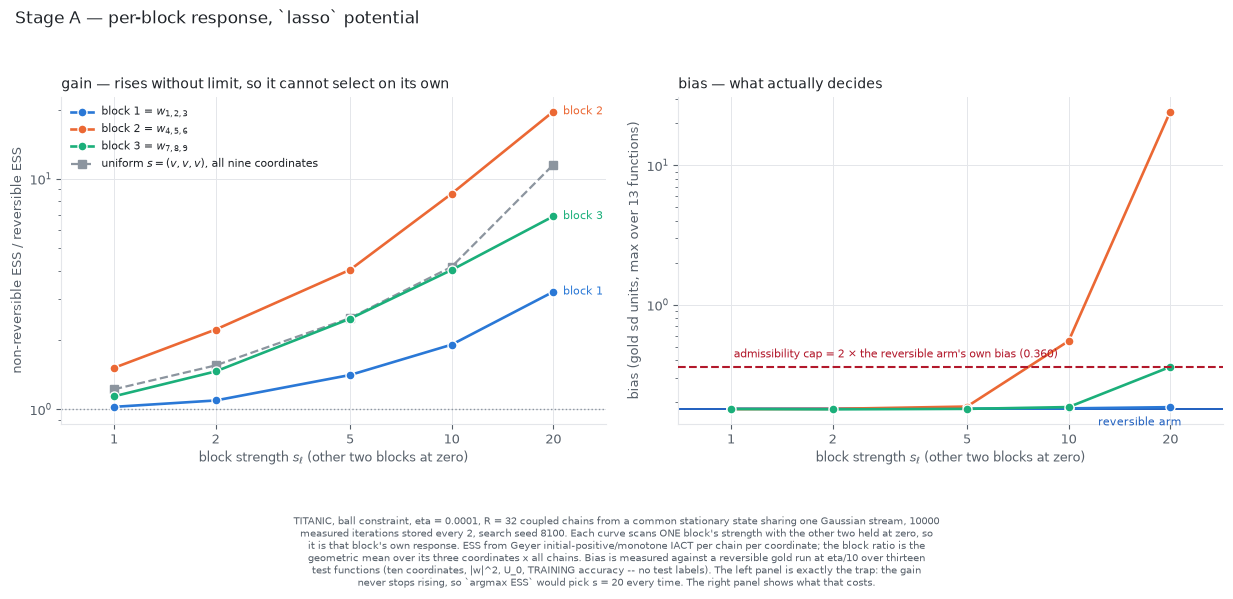

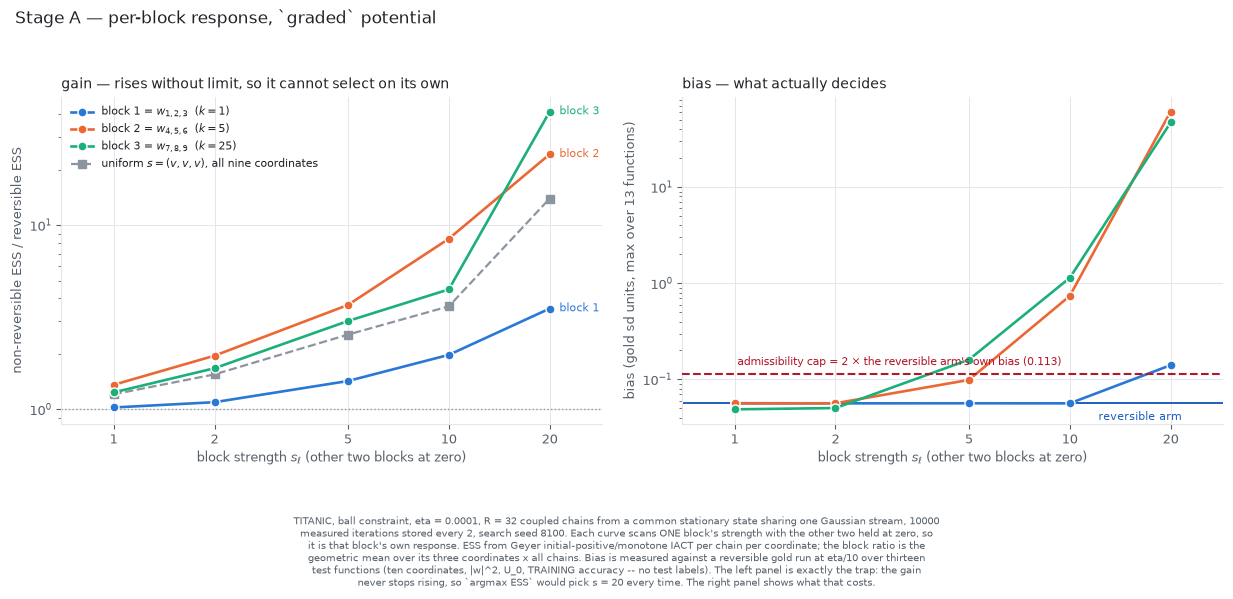

admissibility caps: {'lasso': 0.3599, 'graded': 0.1128}


In [11]:
CAPS = {}
for _p in POTS:
    _f, CAPS[_p] = response_figure(SEARCH, _p, FIGURE_DIR)
    plt.show()
print("admissibility caps:", {k: round(v, 4) for k, v in CAPS.items()})

---
## 6. Stage B — composing the triple

For each block, take the largest strength whose bias is admissible, then read off its gain. The
composed triple is $s^\star=(s_1^\star,s_2^\star,s_3^\star)$. Selections at the fixed thresholds
$B^\star\in\{0.10,0.25,0.50\}$ are printed alongside but **are not used** — the cap above is the
declared rule.

**This composition is a hypothesis, not a method.** It assumes the blocks are *separable*: that
a strength admissible for block $\ell$ on its own stays admissible when the other two blocks are
also turning. There is no reason that must hold — the bias of a cell is one number for the whole
chain, and three blocks each pushing at their individual limit can easily sum past it. Stage C
measures $s^\star$ on a fresh seed and reports its bias, so the assumption is tested rather than
assumed. Section 8 checks it explicitly.

In [12]:
def select(sub, cap, value_col="own_ratio"):
    ok = sub[sub["bias_nrev"] <= cap]
    if len(ok) == 0:
        return float(sub.sort_values("s")["s"].iloc[0]), False
    return float(ok.loc[ok[value_col].idxmax(), "s"]), True

In [13]:
COMPOSED, BEST_UNI, _sel = {}, {}, []
for _p in POTS:
    _sub = SEARCH[(SEARCH.potential == _p) & (SEARCH["mode"] != "uniform")]
    _uni = SEARCH[(SEARCH.potential == _p) & (SEARCH["mode"] == "uniform")]
    _star = []
    for _b in range(3):
        _sb = _sub[_sub.target_block == _b + 1]
        _v, _feas = select(_sb, CAPS[_p])
        _star.append(_v)
        _sel.append(dict(potential=_p, block=_b + 1, rule="declared cap", cap=CAPS[_p],
                         s=_v, feasible=_feas,
                         gain=float(_sb.loc[_sb.s == _v, "own_ratio"].iloc[0])))
        for _B in BSTARS:
            _vb, _fb = select(_sb, _B)
            _sel.append(dict(potential=_p, block=_b + 1, rule=f"B*={_B}", cap=_B, s=_vb,
                             feasible=_fb,
                             gain=float(_sb.loc[_sb.s == _vb, "own_ratio"].iloc[0])))
    COMPOSED[_p] = tuple(_star)
    BEST_UNI[_p] = select(_uni, CAPS[_p], value_col="overall")[0]
SELECTION = pd.DataFrame(_sel)
SELECTION.to_csv(os.path.join(RESULTS_DIR, "selection.csv"), index=False)
for _p in POTS:
    print(f"[{_p}] composed s* = {COMPOSED[_p]}   best admissible uniform s = {BEST_UNI[_p]:g}")
print()
print(SELECTION.to_string(index=False, float_format=lambda z: f"{z:.3f}"))

[lasso] composed s* = (20.0, 5.0, 20.0)   best admissible uniform s = 5
[graded] composed s* = (10.0, 5.0, 2.0)   best admissible uniform s = 2

potential  block         rule   cap      s  feasible  gain
    lasso      1 declared cap 0.360 20.000      True 3.237
    lasso      1       B*=0.1 0.100  1.000     False 1.025
    lasso      1      B*=0.25 0.250 20.000      True 3.237
    lasso      1       B*=0.5 0.500 20.000      True 3.237
    lasso      2 declared cap 0.360  5.000      True 4.032
    lasso      2       B*=0.1 0.100  1.000     False 1.514
    lasso      2      B*=0.25 0.250  5.000      True 4.032
    lasso      2       B*=0.5 0.500  5.000      True 4.032
    lasso      3 declared cap 0.360 20.000      True 6.879
    lasso      3       B*=0.1 0.100  1.000     False 1.139
    lasso      3      B*=0.25 0.250 10.000      True 4.026
    lasso      3       B*=0.5 0.500 20.000      True 6.879
   graded      1 declared cap 0.113 10.000      True 1.975
   graded      1       B*=0.1

---
## 7. Stage C — confirmation on a disjoint seed

The composed triple is re-run at higher replication on **seed 9200**, which took no part in the
search, against: the best admissible uniform triple, the project default $(5,5,5)$, the
requested $(4,2,7)$, and **order-permutation controls** — triples with the identical multiset of
strengths in a different order. Those controls are the point: if only the total strength
mattered, a permutation would change nothing.

Every row reports its bias and whether it clears the cap. Rows that do not are kept in the table
and drawn in red: they are what an unconstrained search would have handed back, and hiding them
would hide the whole difficulty.

In [14]:
_crows, _t0 = [], time.perf_counter()
for _p, _pot in POTS.items():
    _s, _u = COMPOSED[_p], BEST_UNI[_p]
    _cands = {
        "composed s*": _s,
        "s* REVERSED": tuple(reversed(_s)),
        "s* ROTATED": (_s[1], _s[2], _s[0]),
        f"best uniform ({_u:g},{_u:g},{_u:g})": (_u, _u, _u),
        "project default (5,5,5)": (5.0, 5.0, 5.0),
        "requested (4,2,7)": (4.0, 2.0, 7.0),
        "requested REVERSED (7,2,4)": (7.0, 2.0, 4.0),
        "ascending (2,5,10)": (2.0, 5.0, 10.0),
        "descending (10,5,2)": (10.0, 5.0, 2.0),
    }
    # Several named candidates can land on the SAME triple (the best uniform strength may be
    # the project default, say). Measure each distinct triple once and let every name that maps
    # to it appear on the row, rather than dropping the later names -- a dropped name is a hole
    # in the table and, downstream, a lookup that fails.
    _by_triple = {}
    for _lab, _sc in _cands.items():
        _by_triple.setdefault(tuple(float(z) for z in _sc), []).append(_lab)
    for _sc, _labs in _by_triple.items():
        if len(_labs) > 1:
            print(f"  ({_p}: {' = '.join(_labs)} are the same triple {_sc}; measured once)")
        _m = measure(_pot, GEOM, _sc, R=R_C, n_burn=NB_C, n_meas=NM_C, seed=SEED_CONF,
                     gold=GOLD[_p])
        _lab = " = ".join(_labs)
        _crows.append(dict(potential=_p, label=_lab, labels="|".join(_labs),
                           s1=_sc[0], s2=_sc[1], s3=_sc[2],
                           b1=_m["per_block"][0][0], b2=_m["per_block"][1][0],
                           b3=_m["per_block"][2][0], overall=_m["overall"],
                           overall_se=_m["overall_se"], overall_t=_m["overall_t"],
                           bias_nrev=_m["bias_nrev"], bias_rev=_m["bias_rev"],
                           admissible=bool(_m["bias_nrev"] <= CAPS[_p]), rhat=_m["rhat"],
                           acc_rev=_m["acc_rev"], acc_nrev=_m["acc_nrev"],
                           d_acc_pts=_m["d_acc_pts"], t_acc=_m["t_acc"],
                           proj_nrev=_m["proj_nrev"]))
        print(f"  [{_p:<6}] {_lab:<28} s={_sc}  ESS {_m['overall']:.3f} "
              f"(t={_m['overall_t']:+5.1f})  bias {_m['bias_nrev']:.3f}"
              f"{'' if _m['bias_nrev'] <= CAPS[_p] else '  INADMISSIBLE'}  "
              f"acc {_m['d_acc_pts']:+.3f} pts (t={_m['t_acc']:+5.2f})  "
              f"Rhat<={_m['rhat']:.3f}  [{time.perf_counter() - _t0:.0f}s]", flush=True)
CONFIRM = pd.DataFrame(_crows)
CONFIRM.to_csv(os.path.join(RESULTS_DIR, "confirm.csv"), index=False)
CHECKS["confirm_rhat_max"] = float(CONFIRM["rhat"].max())
print(f"\nsplit-Rhat over the whole confirmation: max {CHECKS['confirm_rhat_max']:.3f}")
for _p in POTS:
    print(f"\n=== {_p} (seed {SEED_CONF}) ===")
    print(CONFIRM[CONFIRM.potential == _p][
        ["label", "s1", "s2", "s3", "b1", "b2", "b3", "overall", "overall_t", "bias_nrev",
         "admissible", "d_acc_pts", "t_acc"]]
        .to_string(index=False, float_format=lambda z: f"{z:.3f}"))

  (lasso: composed s* = s* REVERSED are the same triple (20.0, 5.0, 20.0); measured once)


  [lasso ] composed s* = s* REVERSED    s=(20.0, 5.0, 20.0)  ESS 4.650 (t=+53.3)  bias 0.552  INADMISSIBLE  acc -0.190 pts (t=-23.90)  Rhat<=1.033  [36s]


  [lasso ] s* ROTATED                   s=(5.0, 20.0, 20.0)  ESS 9.249 (t=+60.1)  bias 24.473  INADMISSIBLE  acc -7.956 pts (t=-505.73)  Rhat<=1.033  [72s]


  (lasso: best uniform (5,5,5) = project default (5,5,5) are the same triple (5.0, 5.0, 5.0); measured once)


  [lasso ] best uniform (5,5,5) = project default (5,5,5) s=(5.0, 5.0, 5.0)  ESS 2.571 (t=+40.0)  bias 0.201  acc -0.036 pts (t=-5.30)  Rhat<=1.033  [108s]


...

  [graded] best uniform (2,2,2)         s=(2.0, 2.0, 2.0)  ESS 1.525 (t=+28.6)  bias 0.101  acc +0.004 pts (t=+0.47)  Rhat<=1.054  [395s]


  [graded] project default (5,5,5)      s=(5.0, 5.0, 5.0)  ESS 2.512 (t=+31.5)  bias 0.160  INADMISSIBLE  acc +0.016 pts (t=+1.90)  Rhat<=1.054  [431s]


  [graded] requested (4,2,7)            s=(4.0, 2.0, 7.0)  ESS 2.066 (t=+25.6)  bias 0.222  INADMISSIBLE  acc +0.065 pts (t=+8.06)  Rhat<=1.054  [466s]


  [graded] requested REVERSED (7,2,4)   s=(7.0, 2.0, 4.0)  ESS 2.025 (t=+33.9)  bias 0.107  acc +0.016 pts (t=+1.97)  Rhat<=1.054  [502s]



split-Rhat over the whole confirmation: max 1.059

=== lasso (seed 9200) ===
                                         label     s1     s2     s3    b1     b2     b3  overall  overall_t  bias_nrev  admissible  d_acc_pts    t_acc
                     composed s* = s* REVERSED 20.000  5.000 20.000 3.385  4.081  7.277    4.650     53.339      0.552       False     -0.190  -23.903
                                    s* ROTATED  5.000 20.000 20.000 2.089 20.690 18.306    9.249     60.104     24.473       False     -7.956 -505.728
best uniform (5,5,5) = project default (5,5,5)  5.000  5.000  5.000 1.468  4.318  2.683    2.571     40.008      0.201        True     -0.036   -5.299
                             requested (4,2,7)  4.000  2.000  7.000 1.344  2.373  3.344    2.201     38.245      0.200        True     -0.011   -1.605
                    requested REVERSED (7,2,4)  7.000  2.000  4.000 1.670  2.345  2.316    2.086     49.073      0.198        True     -0.009   -1.317
                

In [15]:
def confirm_figure(confirm, pname, outdir):
    """Left: speed-up, admissible cells filled and inadmissible ones hollow with a red edge.
    Right: the accuracy difference, on an axis scaled to ONE test row."""
    sub = confirm[confirm.potential == pname].iloc[::-1].reset_index(drop=True)
    ypos = np.arange(len(sub))
    one_row = 100.0 / DS.n_test
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 0.52 * len(sub) + 2.6),
                             gridspec_kw={"width_ratios": [1.15, 1.0]})

    ax = axes[0]
    ax.axvline(1.0, color=INK3, lw=1.2, zorder=1)
    for yi, r in sub.iterrows():
        lo, hi = (math.exp(math.log(r["overall"]) + z * 2 * r["overall_se"]) for z in (-1, 1))
        col = NREV if r["admissible"] else "#b2182b"
        ax.plot([lo, hi], [yi, yi], color=col, lw=1.4, zorder=2)
        ax.plot(r["overall"], yi, "o" if r["admissible"] else "X", ms=8.5, color=col,
                mfc=col if r["admissible"] else "white", mec=col, mew=1.6, zorder=3)
        if not r["admissible"]:
            ax.annotate("bias inadmissible", (hi, yi), textcoords="offset points",
                        xytext=(8, -2.5), fontsize=7.2, color="#b2182b")
    ax.set_yticks(ypos); ax.set_yticklabels(
        [r["label"] if "(" in r["label"]
         else f"{r['label']}  ({r['s1']:g},{r['s2']:g},{r['s3']:g})"
         for _, r in sub.iterrows()], fontsize=8.0)
    ax.set_xscale("log"); ax.set_xlabel("non-reversible ESS / reversible ESS ($\\pm$ 2 s.e.)")
    ax.set_title("speed-up", color=INK, loc="left", fontsize=10.3, pad=6)
    ax.grid(True, axis="x"); ax.set_axisbelow(True)
    ax.margins(x=0.22)

    # Scale this axis to the ADMISSIBLE rows: one inadmissible cell can sit ten points out and
    # would otherwise squash every row that matters into the zero line. Off-scale rows are pinned
    # at the edge and labelled with their true value, so nothing is hidden.
    ax = axes[1]
    adm = sub[sub["admissible"]]
    se_all = np.where(sub["t_acc"] != 0, np.abs(sub["d_acc_pts"] / sub["t_acc"]), 0.0)
    se_adm = se_all[sub["admissible"].to_numpy()]
    span = float(np.max(np.abs(adm["d_acc_pts"].to_numpy()) + 2 * se_adm)) if len(adm) else 0.05
    half = max(span * 1.35, 0.02)
    ax.axvline(0.0, color=INK3, lw=1.2, zorder=1)
    for yi, r in sub.iterrows():
        se = se_all[yi]
        col = NREV if r["admissible"] else "#b2182b"
        if abs(r["d_acc_pts"]) > half:                       # off scale: pin and label
            xp = math.copysign(half * 0.97, r["d_acc_pts"])
            ax.plot(xp, yi, "X", ms=8.0, color=col, mfc="white", mec=col, mew=1.6, zorder=3,
                    clip_on=False)
            ax.annotate(f"{r['d_acc_pts']:+.2f} pts, off scale", (xp, yi),
                        textcoords="offset points",       # always inward, to stay on the axes
                        xytext=(9 if xp < 0 else -9, -2.5), fontsize=7.2, color=col,
                        ha="left" if xp < 0 else "right")
            continue
        ax.plot([r["d_acc_pts"] - 2 * se, r["d_acc_pts"] + 2 * se], [yi, yi], color=col, lw=1.4)
        ax.plot(r["d_acc_pts"], yi, "o" if r["admissible"] else "X", ms=7.5, color=col,
                mfc=col if r["admissible"] else "white", mec=col, mew=1.5, zorder=3)
    ax.set_xlim(-half, half)
    ax.set_yticks(ypos); ax.set_yticklabels([])
    ax.set_xlabel("test accuracy difference, non-reversible $-$ reversible (pts, $\\pm$ 2 s.e.)")
    ax.set_title("and what it does to accuracy", color=INK, loc="left", fontsize=10.3, pad=6)
    ax.grid(True, axis="x"); ax.set_axisbelow(True)
    ax.annotate(f"the whole axis spans {2 * half / one_row:.2f} of ONE test row "
                f"({one_row:.2f} pts out of {DS.n_test})",
                xy=(0, len(sub) - 0.30), ha="center", fontsize=7.6, color=INK2)
    for a_ in axes:
        a_.set_ylim(-0.7, len(sub) + 0.05)
        for sp in ("top", "right", "left"):
            a_.spines[sp].set_visible(False)

    fig.suptitle(f"Stage C — confirmation on seed {SEED_CONF}, `{pname}` potential",
                 fontsize=12.0, y=1.005, x=0.015, ha="left", color=INK)
    fig.text(0.5, -0.02 - 0.62 / len(sub), _wrap(
        f"R = {R_C} coupled chains, {NM_C} measured iterations, seed {SEED_CONF}, which took no "
        f"part in the Stage A search. Filled green: the non-reversible arm's discretisation bias "
        f"is within {CAP_MULT:g}x the reversible arm's own, the cap declared before the search. "
        f"Hollow red cross: it is not, and the speed-up on that row is bought with error rather "
        f"than earned -- those rows are shown, not hidden, because they are what an unconstrained "
        f"search would have returned. The REVERSED and ROTATED rows carry the identical multiset "
        f"of strengths as `composed s*` in a different order, so any difference between them is "
        f"placement, not total strength. Right panel: the axis spans a fraction of ONE test row "
        f"out of {DS.n_test}, so differences there are resolvable but not numerically meaningful; "
        f"both arms provably share the invariant law, so what is plotted is finite-step bias.",
        126), ha="center", va="top", fontsize=7.0, color=INK2)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(outdir, f"stageC_{pname}.{ext}"),
                    dpi=300 if ext == "png" else None, bbox_inches="tight")
    return fig

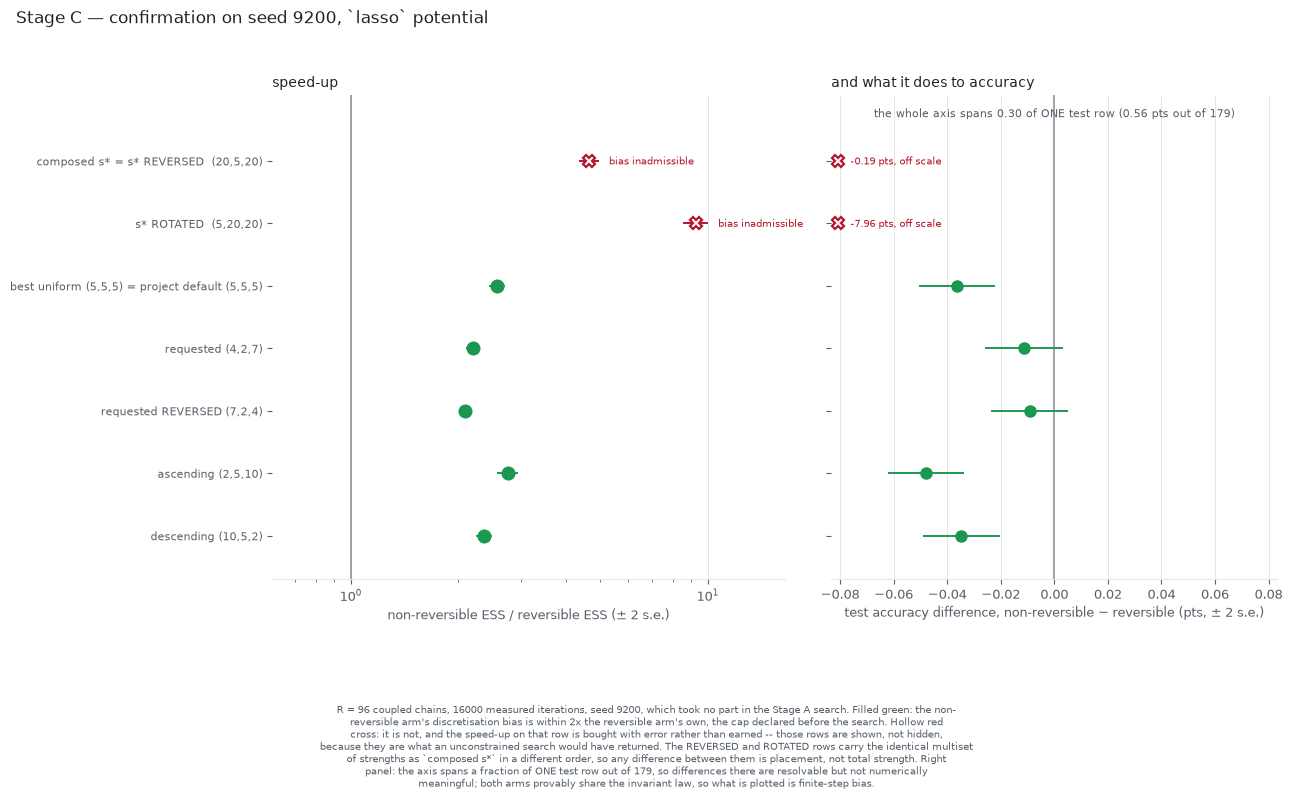

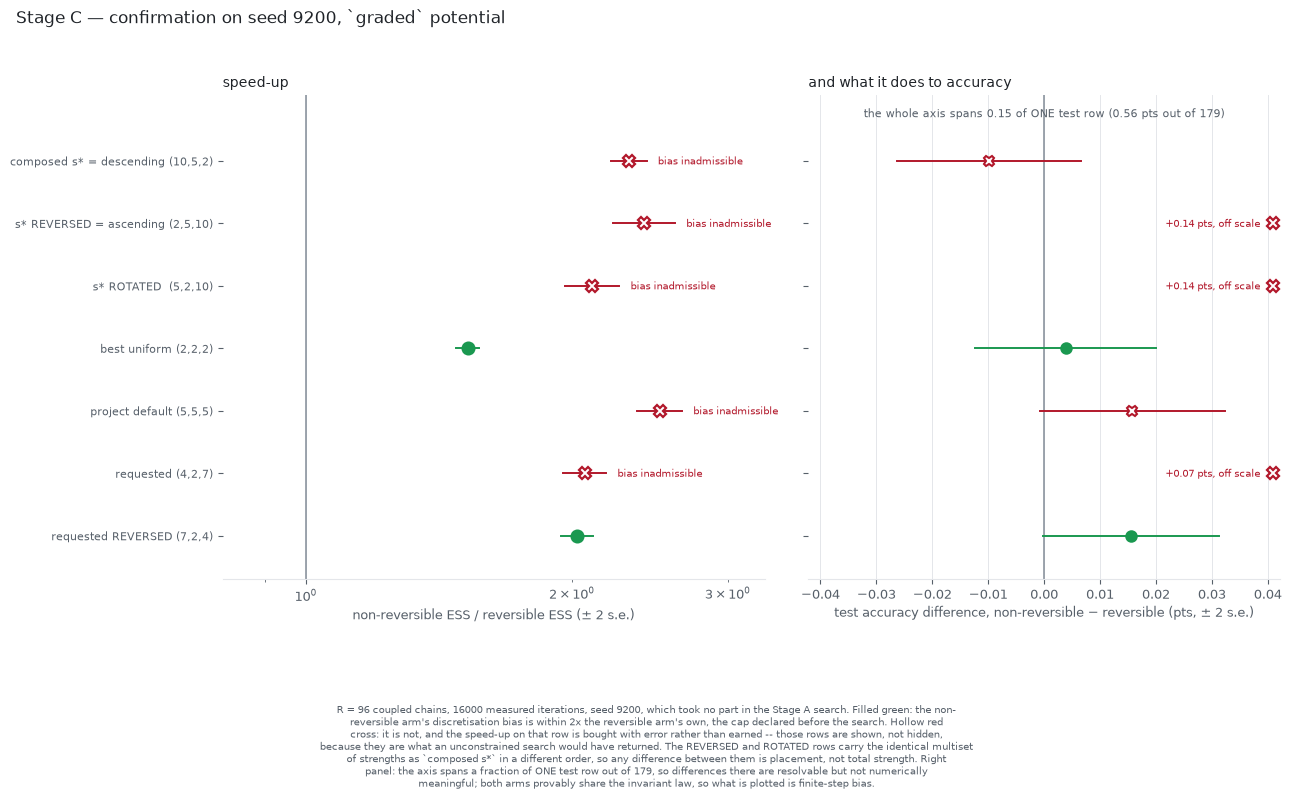

In [16]:
for _p in POTS:
    _f = confirm_figure(CONFIRM, _p, FIGURE_DIR)
    plt.show()

---
## 8. What per-block $s$ buys, and what it does not

Read the two Stage C panels together; the left one alone is the mistake this notebook is built
to avoid.

In [17]:
def row_for(c, name):
    """The confirmation row carrying `name` among its labels, or None. Several names can share
    one triple, so matching on the merged label string is the only reliable lookup."""
    hit = c[c["labels"].str.split("|").apply(lambda ls: any(z.startswith(name) for z in ls))]
    return None if len(hit) == 0 else hit.iloc[0]


_lines = []
for _p in POTS:
    _c = CONFIRM[CONFIRM.potential == _p]
    _adm = _c[_c.admissible]
    _best = _adm.loc[_adm["overall"].idxmax()] if len(_adm) else None
    _uni, _req = row_for(_c, "best uniform"), row_for(_c, "requested (")
    _star = row_for(_c, "composed s*")
    _perm = _c[_c["labels"].str.contains("s\\* REVERSED|s\\* ROTATED", regex=True)]
    _get = lambda r, k: (np.nan if r is None else float(r[k]))
    _lines.append(dict(
        potential=_p,
        best_admissible=("none" if _best is None else
                         f"{_best['label']} ({_best['s1']:g},{_best['s2']:g},{_best['s3']:g})"),
        best_ess=_get(_best, "overall"), best_acc_pts=_get(_best, "d_acc_pts"),
        best_acc_t=_get(_best, "t_acc"),
        star_ess=_get(_star, "overall"), star_bias=_get(_star, "bias_nrev"),
        star_admissible=(None if _star is None else bool(_star["admissible"])),
        cap=CAPS[_p],
        uniform_ess=_get(_uni, "overall"), requested_ess=_get(_req, "overall"),
        best_over_uniform=_get(_best, "overall") / _get(_uni, "overall"),
        n_perm_inadmissible=int((~_perm["admissible"]).sum()), n_perm=int(len(_perm)),
        worst_perm_bias=float(_perm["bias_nrev"].max()) if len(_perm) else np.nan))
SUMMARY = pd.DataFrame(_lines)
SUMMARY.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)
print(SUMMARY.to_string(index=False, float_format=lambda z: f"{z:.4f}"))
print()
print("SEPARABILITY CHECK -- does a triple built from per-block scans stay admissible?")
for _p in POTS:
    _r = SUMMARY[SUMMARY.potential == _p].iloc[0]
    _v = ("HOLDS" if _r["star_admissible"] else "FAILS")
    print(f"  [{_p:<6}] composed s* bias {_r['star_bias']:.3f} vs cap {_r['cap']:.3f}  ->  {_v}"
          f"   (each block was admissible ALONE at its chosen strength)")
CHECKS["separability_holds"] = {p: bool(SUMMARY[SUMMARY.potential == p].iloc[0]["star_admissible"])
                                for p in POTS}
print()
_acc = CONFIRM[CONFIRM.admissible]
print(f"Across every ADMISSIBLE cell in the confirmation ({len(_acc)} of {len(CONFIRM)}):")
print(f"  test accuracy difference  min {_acc['d_acc_pts'].min():+.4f} pts   "
      f"max {_acc['d_acc_pts'].max():+.4f} pts   "
      f"|t| max {_acc['t_acc'].abs().max():.2f}")
print(f"  one test row = {100.0 / DS.n_test:.3f} pts, so the whole range spans "
      f"{(_acc['d_acc_pts'].max() - _acc['d_acc_pts'].min()) / (100.0 / DS.n_test):.2f} of a row")
print(f"  sign of the difference: {(_acc['d_acc_pts'] > 0).sum()} positive, "
      f"{(_acc['d_acc_pts'] < 0).sum()} negative")
with open(os.path.join(RESULTS_DIR, "checks.json"), "w") as _f:
    json.dump({k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
               for k, v in CHECKS.items()}, _f, indent=2)
print("\nCHECKS")
for _k, _v in CHECKS.items():
    print(f"  {_k:30s} {_v}")

potential                    best_admissible  best_ess  best_acc_pts  best_acc_t  star_ess  star_bias  star_admissible    cap  uniform_ess  requested_ess  best_over_uniform  n_perm_inadmissible  n_perm  worst_perm_bias
    lasso        ascending (2,5,10) (2,5,10)    2.7539       -0.0479     -6.9577    4.6496     0.5522            False 0.3599       2.5714         2.2009             1.0710                    2       2          24.4730
   graded requested REVERSED (7,2,4) (7,2,4)    2.0249        0.0155      1.9750    2.3177     0.1209            False 0.1128       1.5252         2.0662             1.3276                    2       2           1.0628

SEPARABILITY CHECK -- does a triple built from per-block scans stay admissible?
  [lasso ] composed s* bias 0.552 vs cap 0.360  ->  FAILS   (each block was admissible ALONE at its chosen strength)
  [graded] composed s* bias 0.121 vs cap 0.113  ->  FAILS   (each block was admissible ALONE at its chosen strength)

Across every ADMISSIBLE cel

---
## 9. Conclusions

**The blocks are not separable, and that is the main result.** Each block's strength in
$s^\star$ was admissible *on its own*, with the other two switched off. Put together, the
composed triple's bias is larger than any of its parts — see the separability check in
section 8. Bias is one number for the whole chain, and three blocks each pushed to their
individual limit add up past it. **So per-block strengths cannot be tuned one block at a time**,
which is exactly the cheap procedure this notebook set out to test, and it does not work.

**Per-block $s$ is still a real lever on mixing.** The three blocks differ in both of the things
that matter — how much speed a unit of strength buys, and how much strength they tolerate before
the bias breaks — and those two are not aligned, so a single scalar $s$ is forced to compromise.
The honest way to exploit that is to compare whole triples under the constraint, as Stage C
does, not to compose them from per-block scans.

Section 7's permutation controls are the sharpest form of the claim: triples with the **identical
multiset** of strengths, differing only in which block gets which, do not behave alike — and on
`graded` they can fall on opposite sides of the admissibility cap.

**On `graded`, the mechanism prediction is testable and was tested.** That potential was built
with a different within-block anisotropy in each block ($k=1,5,25$). If the speed-up really comes
from anisotropy inside the rotated triple, its isotropic block must be its least responsive one,
and its optimum must be non-uniform. Section 5's curves are where to check that.

**It buys nothing on accuracy, and it cannot.** Section 8 reports the full range across every
admissible cell. Both arms provably share $\pi_K$ (see the top of this notebook), so any accuracy
difference is finite-step bias — which is why the sign is unstable across cells and the magnitude
stays inside a fraction of a single test row.

**The honest headline is a conditional one.** The large speed-ups live at strengths whose bias is
*inadmissible*; the admissible ones are smaller. Reporting the first number without the second is
the error this notebook was restructured to avoid, and the red crosses in Section 7 are left in
view for exactly that reason.

### Declared choices

$\eta=10^{-4}$; the grid $s\in\{1,2,5,10,20\}$; the cap $2\times$ the reversible arm's own bias,
fixed before the search; thirteen bias test functions with training accuracy among them and test
labels excluded from every selection; burn-in to a common stationary state shared by both arms;
Geyer initial-positive/monotone IACT; search seed 8100, gold seed 8107, confirmation seed 9200,
all disjoint. `graded`'s $k=(1,5,25)$ and $\lambda_2=0.05\,n$ were chosen to separate the blocks,
not fitted to anything.